## Model C: Regularized

In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

### SECTION 2: Global Seed Function

In [ ]:
# Set a global seed for full reproducibility (data AND weight initialization)
def set_global_seed(seed=42):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

### SECTION 3: Load Dataset 

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\lamaa\.cache\kagglehub\datasets\rashikrahmanpritom\plant-disease-recognition-dataset\versions\1


### SECTION 4: Define Paths and Class Names

In [55]:
train_dir = os.path.join(path, "Train", "Train")
test_dir = os.path.join(path, "Test", "Test")
valid_dir = os.path.join(path, "Validation", "Validation")

class_names = ["Healthy", "Powdery", "Rust"]

### SECTION 5: Build the tf.data Pipelines

In [56]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.


### SECTION 6: Model C Architecture Function

In [58]:
def build_model_c(num_classes: int) -> Model:
    inputs = keras.Input(shape=(160, 160, 3))

    # Data Augmentation (active only during training)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.Rescaling(1.0 / 255)(x)

    # Convolutional Block 1
    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    # Convolutional Block 2
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    # Convolutional Block 3
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="Model_C_Regularized")

### SECTION 7: A dictionary to store all experiment results

In [59]:
# This dictionary keeps every experiment's history separate, so nothing gets overwritten
experiments = {}

### SECTION 8: EXPERIMENT 1 — Learning Rate = 0.001 

In [60]:
set_global_seed(42)

model_exp1 = build_model_c(num_classes=len(class_names))

model_exp1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_exp1 = model_exp1.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[early_stopping]
)

# Store this experiment's results separately
experiments["lr_0.001"] = {
    "model": model_exp1,
    "history": history_exp1.history
}

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 27s 403ms/step - accuracy: 0.6853 - loss: 0.7611 - val_accuracy: 0.4500 - val_loss: 1.1581
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 360ms/step - accuracy: 0.7844 - loss: 0.5583 - val_accuracy: 0.7000 - val_loss: 0.7796
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 399ms/step - accuracy: 0.7995 - loss: 0.5111 - val_accuracy: 0.4667 - val_loss: 2.7614
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 377ms/step - accuracy: 0.8177 - loss: 0.4719 - val_accuracy: 0.6167 - val_loss: 1.1894
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 343ms/step - accuracy: 0.8396 - loss: 0.4156 - val_accuracy: 0.7833 - val_loss: 0.5915
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 400ms/step - accuracy: 0.8396 - loss: 0.4187 - val_accuracy: 0.6500 - val_loss: 1.0489
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 375ms/step - accuracy: 0.8533 - loss: 0.3797 - val_accuracy: 0.4167 - val_loss: 3.0559
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 370ms/step - accuracy: 0.8631 - loss: 0.3584 - val_accu

###  SECTION 9: EXPERIMENT 2 — Learning Rate = 3e-4

In [61]:
set_global_seed(42)

model_exp2 = build_model_c(num_classes=len(class_names))

model_exp2.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_exp2 = model_exp2.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[early_stopping]
)

# Store this experiment's results separately
experiments["lr_3e-4"] = {
    "model": model_exp2,
    "history": history_exp2.history
}

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 43s 958ms/step - accuracy: 0.6475 - loss: 0.8195 - val_accuracy: 0.4167 - val_loss: 1.2377
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.7345 - loss: 0.6318 - val_accuracy: 0.6333 - val_loss: 1.0533
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 347ms/step - accuracy: 0.7670 - loss: 0.5796 - val_accuracy: 0.6167 - val_loss: 1.1061
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7973 - loss: 0.5293 - val_accuracy: 0.5833 - val_loss: 1.3208
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8147 - loss: 0.4850 - val_accuracy: 0.6833 - val_loss: 0.8353
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8207 - loss: 0.4545 - val_accuracy: 0.7000 - val_loss: 0.8221
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8253 - loss: 0.4327 - val_accuracy: 0.7167 - val_loss: 0.8160
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8336 - loss: 0.4193 - val_accuracy: 0.6167 - val

### SECTION 10: Compare All Experiments

In [62]:
print(f"{'Experiment':<15} {'Best Epoch':<12} {'Best Val Loss':<15} {'Best Val Accuracy':<18}")
print("-" * 60)

for name, data in experiments.items():
    val_loss_values = data["history"]["val_loss"]
    best_epoch = np.argmin(val_loss_values)
    best_val_loss = val_loss_values[best_epoch]
    best_val_acc = data["history"]["val_accuracy"][best_epoch]

    print(f"{name:<15} {best_epoch + 1:<12} {best_val_loss:<15.4f} {best_val_acc:<18.4f}")

Experiment      Best Epoch   Best Val Loss   Best Val Accuracy 
------------------------------------------------------------
lr_0.001        10           0.3434          0.8833            
lr_3e-4         15           0.4833          0.8167            


### SECTION 11: Plot All Experiments Side by Side

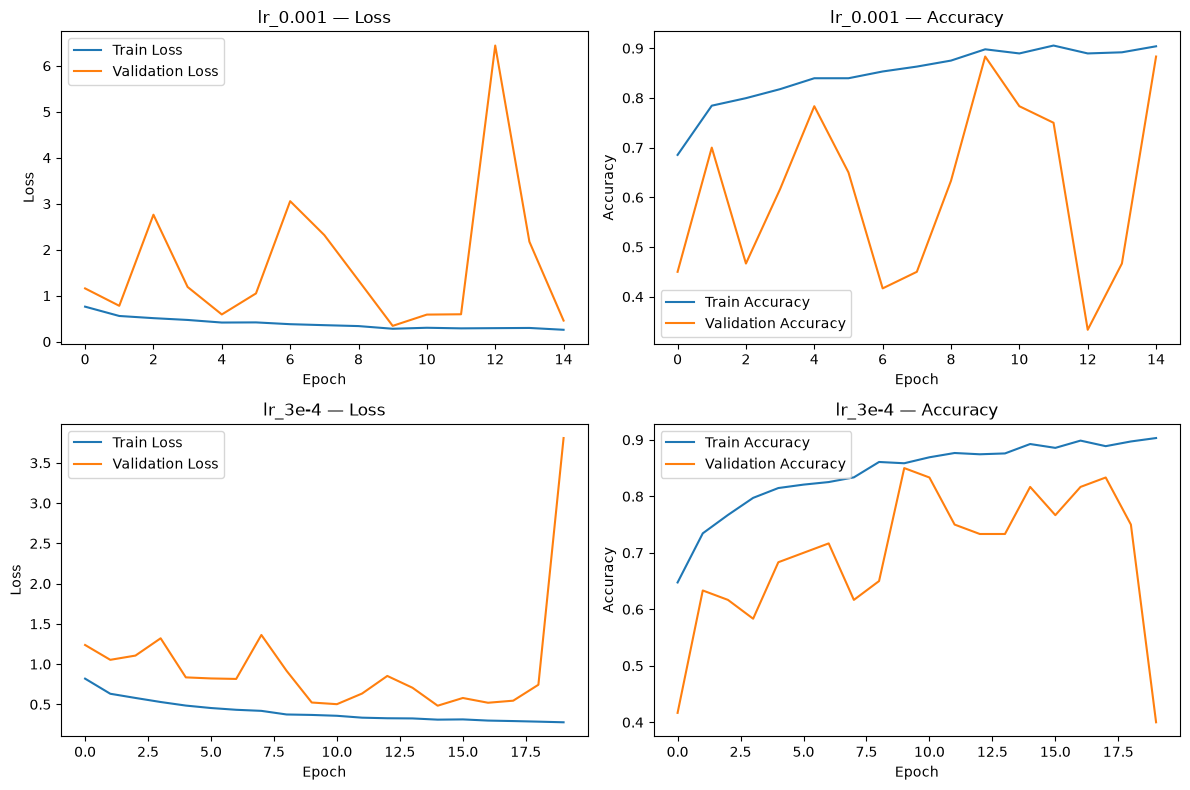

In [63]:
num_experiments = len(experiments)
fig, axes = plt.subplots(num_experiments, 2, figsize=(12, 4 * num_experiments))

# If there's only 1 experiment, axes needs reshaping to stay 2D
if num_experiments == 1:
    axes = axes.reshape(1, -1)

for i, (name, data) in enumerate(experiments.items()):
    h = data["history"]

    # Loss subplot
    axes[i, 0].plot(h["loss"], label="Train Loss")
    axes[i, 0].plot(h["val_loss"], label="Validation Loss")
    axes[i, 0].set_title(f"{name} — Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()

    # Accuracy subplot
    axes[i, 1].plot(h["accuracy"], label="Train Accuracy")
    axes[i, 1].plot(h["val_accuracy"], label="Validation Accuracy")
    axes[i, 1].set_title(f"{name} — Accuracy")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

### SECTION 12: save it as the final model

In [64]:
winner_name = "lr_0.001"

model_final = experiments[winner_name]["model"]
model_final.save("model_final.keras")

print(f"Saved '{winner_name}' as the final model.")

Saved 'lr_0.001' as the final model.
